In [21]:
import os
import sys
import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgbm

from utils import user_utils

In [10]:
row_df = pd.read_csv('../data/creditcard.csv')
row_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
def get_outlier(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
    
    # 사분위수 계산
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    # 이상치 마스크
    outlier_mask = pd.DataFrame(False, index=df.index, columns=columns)
    for col in columns:
        outlier_mask[col] = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    
    # 결과 요약
    outlier_bounds = pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": outlier_mask.sum()
    })
    
    return outlier_bounds


In [12]:
get_outlier(row_df)

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
Time,54201.500000,139320.500000,85119.000000,-73477.000000,266999.000000,0
V1,-0.920373,1.315642,2.236015,-4.274396,4.669664,7062
V2,-0.598550,0.803724,1.402274,-2.701961,2.907135,13526
V3,-0.890365,1.027196,1.917560,-3.766705,3.903536,3363
V4,-0.848640,0.743341,1.591981,-3.236612,3.131313,11148
V5,-0.691597,0.611926,1.303524,-2.646882,2.567212,12295
V6,-0.768296,0.398565,1.166861,-2.518586,2.148856,22965
V7,-0.554076,0.570436,1.124512,-2.240844,2.257204,8948
V8,-0.208630,0.327346,0.535976,-1.012593,1.131309,24134
V9,-0.643098,0.597139,1.240237,-2.503452,2.457494,8283


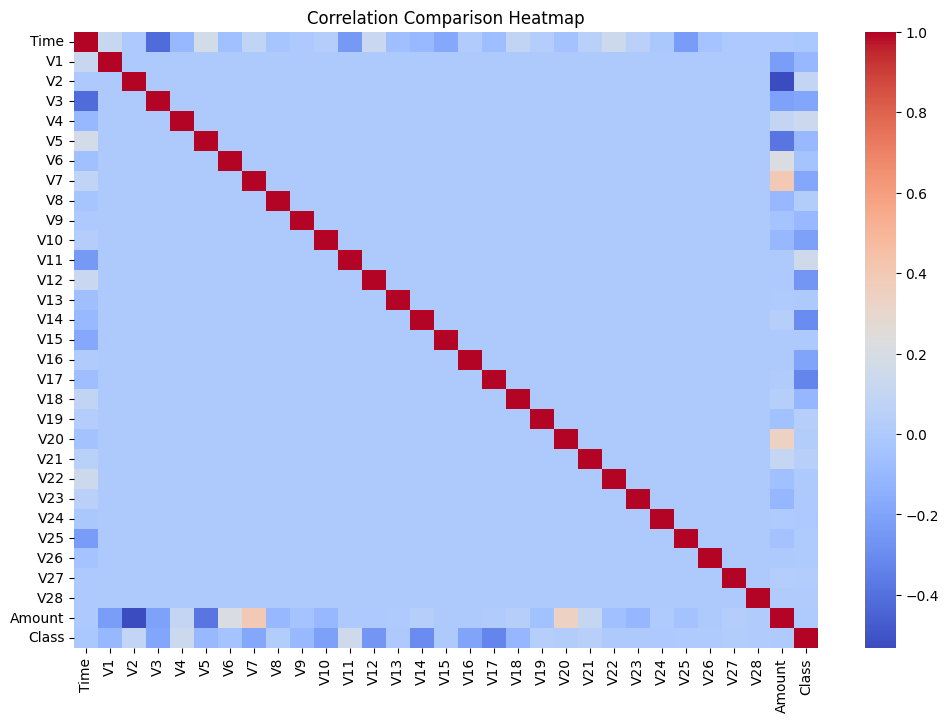

In [23]:
columns = row_df.select_dtypes(include="number").columns
corr_matrix = row_df[columns].corr()
    
    # 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Comparison Heatmap")
plt.show()
